# Generation of log and uvflg file from sensors

Conditions for setting uvflg:
- number of antennas locked on target is below quorum
- target doesn't match VLBI catalogue target (i.e. when doing phase-up)

Rev a:
- uvflag file generation

Rev b:
- generating a log file containing exerpts from MeerKAT observation script log, as well as GPS-maser offset.

Rev 1:
- Cleaned up / documented as standalone version.

Rev 2:
- updated catalogue parsing function for phase-up correction parameters in schedule file header.
- addressing case-sensitivity on valid_scans definition


In [1]:
# Experiments

# EVN Session 1:
# n24l3, 1729171747
# n25l1, 1740055990
# em181a, 1740224791
# es116a, 1740943459

# EVN Session 2:
# n25l2: 1749383603
# em180a: 1749409153
# ed051a: 1749724290
# em180b: 1749814757

# LBA test, 14-08-2025
# vt33a: 1755154278

# EVN Session 3 2025
# n25l3 comments: 
# - Note that there are distinct CSV catalogue files for 18 and 21cm. Rename each appropriately when doing analysis for that band.
# - Except for the cal scans, there's no need to rename the power output files since these are labelled per scan. Cal scans with the same
#   number from different observations will be overwritten, though that doesn't really matter. In future, use different cal scan numbers 
#   in the different observations.
# - the auxiliary files however require significant changes, as both observations need to be combined into one file.
# n25l3, 1761049693 (18cm).  
# n25l3, 1761056293 (21cm).
# el079b, 1761145885
# gg090, 1761508048


In [2]:
# Main parameters

# VLBI Experiment name (sets the observation catalogue file name)
exp_name = 'pcctest'
# NARROWBAND observation RDB file corresponding to the experiment
obs_cbid = "1769593762"
# Station code
station_code = 'me'
# Valid scan prefix. Prefix of scans to be included in log file.
validscan_prefix = 'scan no'
#validscan_prefix = None  # For debugging.

# Log file options
log_script = True
log_sensors = True
# Set true for running while portal is offline
portal_offline = False

# Antenna quorum for validity conditions
quorum = 0.90
# Flag / log file time resolution, in seconds.
log_interval = 1  
# Sensor reporting interval, in seconds. 
sensor_interval = 60 

# Observation catalogue directory
cat_dir = '/home/mgouws/vlbi/catalogues/'
# Output directory for calibration files
log_dir = '/home/mgouws/vlbi/metadata/'
# Location to download rdb files
rdb_dir = '/home/mgouws/vlbi/rdb_files/'


In [3]:
# Imports and definitions

import numpy as np
import os.path
import requests
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from datetime import datetime, timedelta, timezone
from astropy.time import Time as ap_time
import katdal
import katpoint


def parse_vlbi_cat(vlbi_cat_fn, proc_buffer_sec=1, ref_ant=None):
    """ Parses the provided VLBI catalogue file and provides a list of scan parameters and
    a katpoint catalogue of unique targets in the observation. 

    Parameters
    ----------
    vlbi_cat_fn : string
        Location of text file containing observation scan information
    proc_buffer_sec : integer 
        Buffer time in seconds added before and after processing start and 
        stop time. 
    ref_ant : katpoint Antenna object
        Reference antenna for katpoint Catalogue

    Returns
    -------
    obs_params : Dictionary
        Dictionary with observation parameters.
    scan_params : list of dictionaries
        List of dictionaries with paramters for each scan.
    vlbi_cat : katpoint Catalogue object
        katpoint catalogue with unique targets to be observed.
        
    """
    # Read the VLBI catalogue file 
    with open(vlbi_cat_fn, 'r') as cat_file:
        csv_lines = [line for line in cat_file.readlines()]
    # Read header info
    header_lines = [line[1:].strip() for line in csv_lines if line.startswith('#')]
    hdr_keys = ['EXPERIMENT', 'POL', 'CAL_PREFIX', 'PCC_PREFIX', 'PCC_VERIFICATION'] 
    obs_params = dict.fromkeys(hdr_keys)
    obs_params['CHANNELS'], hdr_ch_key = {}, 'CH'
    for line in header_lines:
        hdr_key, hdr_par = line.split(' ')[0], line.split(' ')[1:]
        if hdr_key in hdr_keys:
            obs_params[hdr_key] = ' '.join(hdr_par)
        elif line.startswith(hdr_ch_key):
            obs_params['CHANNELS'][hdr_key] = hdr_par
    # Create list of scan parameters
    scan_params = {}
    scan_lines = [line for line in csv_lines if not line.startswith('#')]
    for scan_line in scan_lines:
        # Scan name
        scan_name = scan_line.split(',')[-3].strip()
        # Datetime of scan start time
        start_time_str = scan_line.split(',')[-2].strip()
        start_time = datetime.strptime(start_time_str, '%Y-%m-%d %H:%M:%S.%f')
        start_time = start_time.replace(tzinfo=timezone.utc)
        # Start time for processing of scan
        start_time_proc = start_time - timedelta(seconds=proc_buffer_sec)  
        # Duration
        duration = int(scan_line.split(',')[-1])
        # Target name
        tgt_string = scan_line.split(',')[0].split('|')[0].strip()
        tgt_string = tgt_string[1:] if tgt_string.startswith('*') else tgt_string
        # Create a katpoint target line
        kp_target_ln = ', '.join([kp.strip(' ') for kp in scan_line.split(',')[:-3]]) 
        # Store scan parameters
        scan_params[scan_name] = {'target':tgt_string,
                                  'start_iso':scan_line.split(',')[-2],
                                  'start_ts':start_time.timestamp(),
                                  'duration':duration,
                                  'kp_tgt':katpoint.Target(kp_target_ln, antenna=ref_ant),
                                  'proc_start_iso':start_time_proc.strftime('%Y-%m-%dT%H:%M:%S.%f'),
                                  'proc_start_ts':start_time_proc.timestamp(),                               
                                  'proc_duration':duration+2*proc_buffer_sec}
    # Sort dictionary entries by scan start time
    sorted_params = sorted(scan_params.items(), key=lambda e:e[1]['start_ts'])
    scan_params = dict(sorted_params)
    # Create a katpoint catalogue for unique targets
    kp_target_list = []
    for scan_name, scan_pars in scan_params.items():
        if scan_pars['kp_tgt'] not in kp_target_list:
            kp_target_list.append(scan_pars['kp_tgt'])
    vlbi_cat = katpoint.Catalogue(kp_target_list, antenna=ref_ant)
    return obs_params, scan_params, vlbi_cat


def get_sensor(sensorname, start_time, end_time, timeout=100,
               store_url="http://portal.mkat.karoo.kat.ac.za/katstore/api/query"):
    """ Retrieves data from the CAM sensor database with an http request.
    
    Parameters
    ----------
    sensorname : string
        Name of the sensor to retrieve, e.g. 'm004_dig_l_band_rfcu_hpol_rf_power_in'
    start_time : unix timestamp
        Start time of sensor database search.
    end_time : unix timestamp
        End time of sensor database search.
    timeout : integer, optional
        Timeout time for http request, in seconds. (Default=100)
    store_url : string, optional
        URL of the desired sensor portal. (Default="http://portal.mkat.karoo.kat.ac.za/katstore/api/query")
        
    Returns
    -------
    times, values : array
        Retrieved timestamps and values of requested sensor.
        
    """
    params={'sensor': sensorname,  # name of the sensor.
            'start_time': start_time, # start time in sec
            'end_time': end_time, # end time in sec
            'limit':10000000}
    try:
        res = requests.get(store_url, params, timeout=timeout) # Submit the query
        res.raise_for_status()  # Raise exception on status errors
        # Data comes back as JSON with the correct mime type set so can be converted by Requests
        data_list = np.asarray([(r['sample_time'], r['value']) for r in res.json()['data']])
    except Exception as e:
        print("Failed to connect to %s: \n%s" % (store_url,e))
        data_list = np.array([])
    if (np.shape(data_list)[0] == 0):
        return (np.asarray([]), np.asarray([]))
    else:
        _t, _v = np.asarray(data_list[:,0], dtype=float), data_list[:,1] 
        return (_t, _v)


class text_file_man():
    """ Simple text file creation functions.
    """
    def __init__(self):
        """ Initialise file lines. """
        self.file_lines = []

    def add_line(self, line_string):
        """ Append provided string as line to file.
        """
        self.file_lines.append(line_string)

    def write_to_file(self, fn_out):
        """ Write all text lines out to provided file name. """
        with open(fn_out, 'w') as out_file:
            for line in self.file_lines:
                out_file.write(line)
                out_file.write('\n')

    def print_all(self):
        """ Print all text lines for inspection. """
        for line in self.file_lines:
            print(line)


def get_flagged_ranges(timestamps, data_valid):
    """ Return time periods where data is invalid as a list of start/stop timestamp tuples. 
    
    Parameters
    ----------
    timestamps : Numpy ndarray
        Array of unix time stamps corresponding to the data valid signal. 
    data_valid : Numpy boolean ndarray 
        Boolean array that is True if data is valid.
        
    Returns
    -------
    ts_rng : list of tuples
        List of (start timestamp, stop timestamp) indicating where data_valid is False.
    
    """
    # Find valid and invalid indices
    data_args = np.arange(len(data_valid))
    invalid_args = data_args[data_valid==0]
    if len(invalid_args)>1:
        # Find beginning/end of discontinuous arguments
        invalid_beg = invalid_args[np.r_[True, np.diff(invalid_args)>1]]
        invalid_end = invalid_args[np.r_[np.diff(invalid_args)>1, True]]
        # Create list of beginning/ending timestamp tuples
        ts_rng = []
        for ii_beg, ii_end in zip(invalid_beg, invalid_end):
            ts_rng.append((timestamps[ii_beg],timestamps[ii_end]))
    else:
        ts_rng = None
    return ts_rng


class log_manager():
    """ Functions for managing log creation. A log is represented by a list of entries. 
    Each entry is a dictionary that includes (i) a 'time' field with a datetime object 
    representing log entry time, (ii) a 'key' field with a string label indicating the 
    type of entry, and (iii) a 'line' field containing the line text.
    """
    
    def __init__(self):
        """ Initialise log """
        self.log = []

    def add_entry(self, log_entry):
        """ Add entry to log. """
        self.log.append(log_entry)

    def get_logtime(self, ii_entry):
        """ Return time at specified entry index """
        return self.log[ii_entry]['time']

    def sort_entries(self):
        """ Sort entries by log entry time. """
        # Sort by unix timestamp
        sort_fcn = lambda e : e['time'].timestamp()
        self.log.sort(key=sort_fcn)
        #sorted_entries = sorted(self.log.items(), key=lambda e:e[1]['time'].timestamp())
        #self.log = dict(sorted_entries)

    def print_log(self):
        """ Print log. """
        for log_entry in self.log:
            # Set output format
            log_time = log_entry['time'].isoformat(sep=' ', timespec='milliseconds')
            # Truncate tzinfo
            log_time = log_time.split('+')[0]
            print(log_time, log_entry['key'], log_entry['line'])

    def write_to_file(self, fn_out):
        """ Write all text lines to specified file. """
        with open(fn_out, 'w') as out_file:
            for log_entry in self.log:
                # Set output format
                log_time = log_entry['time'].isoformat(sep=' ', timespec='milliseconds')
                # Truncate tzinfo
                log_time = log_time.split('+')[0]
                file_line = ' '.join([log_time, log_entry['key'], log_entry['line']])
                out_file.write(file_line)
                out_file.write('\n')



In [4]:
# Load RDB file and set parameters

# Set RDB address and file name
addr_rdb = 'http://archive-gw-1.kat.ac.za/'+obs_cbid+'/'+obs_cbid+'_sdp_l0.full.rdb'
fn_rdb = rdb_dir+obs_cbid+'_sdp_l0.full.rdb'
# Download RDB file
if not os.path.exists(fn_rdb):
    !wget -P $rdb_dir $addr_rdb

# Open rdb file and load obs parameters.
d = katdal.open(fn_rdb)
ant_names = [ant.name for ant in d.ants]
n_ants = len(ant_names)
pols = d.source.telstate['cal_pol_ordering']
obs_start_time = d.start_time.secs
obs_end_time = d.end_time.secs

# Load and parse observation VLBI catalogue
vlbi_cat_file = 'vlbi_cat_{}.csv'.format(exp_name)
_, scan_data, _ = parse_vlbi_cat(cat_dir+vlbi_cat_file)
# Identify valid scans (i.e. exclude phase-up calibration scans)
# Set names of scans to be included in the antab file.
if validscan_prefix:
    # Include only scans that start with the specified prefix
    valid_scans = [sn for sn in scan_data.keys() if sn.lower().startswith(validscan_prefix)]
else:
    # Include all scans.
    valid_scans = [sn for sn in scan_data.keys()]

# Set log time axis and target
# - for now only including times during valid VLBI scans
timestamps_log, scan_target_log = [], []
for scan_name in valid_scans:
    # Select scan
    scan_pars = scan_data[scan_name]
    # Create scan time axis
    scan_start = int(scan_pars['start_ts'])
    scan_stop = scan_start + int(scan_pars['duration'])
    scan_time_range = range(scan_start, scan_stop+log_interval, log_interval)
    timestamps_log += scan_time_range
    # Set corresponding target
    scan_target_log += [scan_pars['target']]*len(scan_time_range)
timestamps_log = np.sort(timestamps_log)
n_ts = len(timestamps_log)


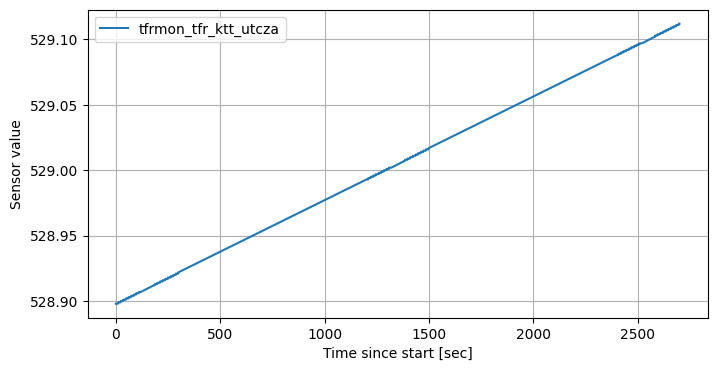

In [5]:
# Load data for all required sensors and interpolate onto log time axis.

if not portal_offline:
    
    # Set sensor names to load
    sensor_names = []
    # Antenna activity (valid value: 'track')
    for ant in ant_names:
        # Antenna status sensors for uvflg file
        sensor_names.append("{}_activity".format(ant))
        sensor_names.append("{}_target".format(ant))
        # Sensors for log file
        #sensor_names.append("tfrmon_tfr_ktt_gnss".format(ant))
        #sensor_names.append("tfrmon_tfr_ktt_gnss_15min".format(ant))
        sensor_names.append("tfrmon_tfr_ktt_utcza".format(ant))
        #sensor_names.append("tfrmon_tfr_ktt_utcza_15min".format(ant))
    
    # Get sensor values
    sensor_data = {}
    for sensor_name in sensor_names:
        # Read sensor values
        timestamps, values = get_sensor(sensor_name, obs_start_time, obs_end_time)
        # Interpolate sensor values onto log time axis
        arg_interp = [np.argmin(np.abs(ts_log-timestamps)) for ts_log in timestamps_log]
        sensor_data[sensor_name] = values[arg_interp]

    # Plot selected sensor data for inspection 
    plt.figure(figsize=(8,4))
    #plt.plot(timestamps_log-timestamps_log[0], sensor_data['tfrmon_tfr_ktt_gnss'])
    #plt.plot(timestamps_log-timestamps_log[0], sensor_data['tfrmon_tfr_ktt_gnss_15min'])
    plt.plot(timestamps_log-timestamps_log[0], sensor_data['tfrmon_tfr_ktt_utcza'], label='tfrmon_tfr_ktt_utcza')
    #plt.plot(timestamps_log-timestamps_log[0], sensor_data['tfrmon_tfr_ktt_utcza_15min'])
    plt.grid(); plt.legend()
    plt.xlabel('Time since start [sec]')
    plt.ylabel('Sensor value')
    
    plt.show()


! The following is flagging information for ME in experiment pcctest,
! extracted on 2026-01-28.
opcode='FLAG'
dtimrang = 1   timeoff=0
ant_name='ME' timerang=028,10,05,59, 028,10,06,00 reason='Antenna off source' /
ant_name='ME' timerang=028,10,25,58, 028,10,26,00 reason='Antenna off source' /
ant_name='ME' timerang=028,10,45,58, 028,10,46,00 reason='Antenna off source' /
ant_name='ME' timerang=028,10,48,58, 028,10,49,00 reason='Antenna off source' /


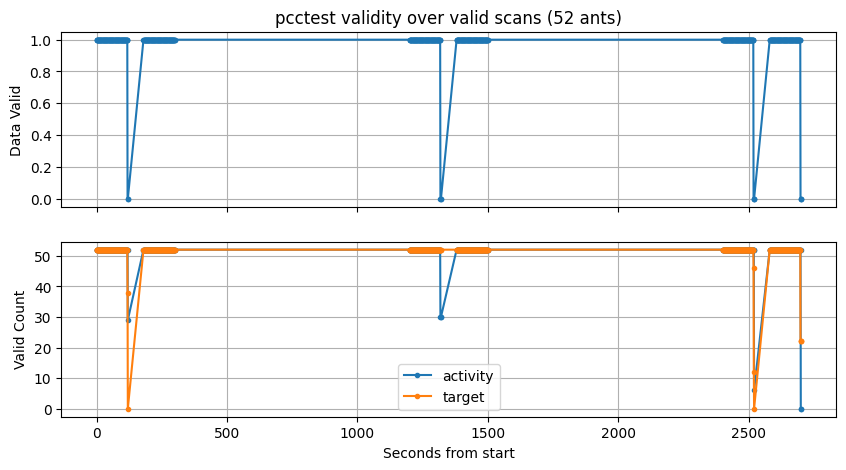

In [6]:
# Generate uvflg file    

if portal_offline:

    data_valid = np.zeros(n_ts).astype('bool')

else:

    # Evaluate sensor validity conditions: activity 
    ant_activity_valid = np.zeros((n_ants, n_ts))
    for ii_a, ant in enumerate(ant_names):
        values = sensor_data["{}_activity".format(ant)]
        ant_activity_valid[ii_a,:] = np.array(values)=='track'
    activity_valid = np.sum(ant_activity_valid, axis=0)>=n_ants*quorum
    
    # Evaluate sensor validity conditions: target 
    ant_target_valid = np.zeros((n_ants, n_ts))
    for ii_a, ant in enumerate(ant_names):
        values = sensor_data["{}_target".format(ant)]
        if False:
            print(ii_a, ant)
            for tgt_str in values:
                try:
                    test_tgt = katpoint.Target(tgt_str)
                    if ii_a==10 or ii_a==9:
                        print('PASS', ii_a, ant, tgt_str)
                except Exception as e:
                    print('FAIL', ii_a, ant, tgt_str, e)
        try:
            values = [katpoint.Target(tgt_str).name for tgt_str in values]
        except:
            #FIXME: Hack to accommodate malformed target sensor strings, e.g. 1755154278 on m049
            # Assume target name is first field in string. This may fail if the preferred name indicator '*' doesn't fall on the first field.
            print('WARNING: Malformed katpoint target strings on {}.'.format(ant))
            values = [tgt_str.split(' ')[0].strip('*') for tgt_str in values]
        ant_target_valid[ii_a,:] = np.array(values)==np.array(scan_target_log)
    target_valid = np.sum(ant_target_valid, axis=0)>=n_ants*quorum
    
    # Combine conditions
    data_valid = np.logical_and(activity_valid,
                                target_valid)

# Plot overview of validity condition over time
fig, axs = plt.subplots(2,1, figsize=(10,5), sharex=True)
axs[0].plot(timestamps_log-timestamps_log[0], data_valid , '.-')
axs[1].plot(timestamps_log-timestamps_log[0], np.sum(ant_activity_valid, axis=0) , '.-', label='activity')
axs[1].plot(timestamps_log-timestamps_log[0], np.sum(ant_target_valid, axis=0) , '.-', label='target')
axs[0].set_title("{} validity over valid scans ({} ants)".format(exp_name, n_ants))
axs[1].set_xlabel('Seconds from start')
axs[0].set_ylabel('Data Valid')
axs[1].set_ylabel('Valid Count')
axs[1].legend()
axs[0].grid(); axs[1].grid()
#axs[1].set_xlim([0,1000])

# Initialise file object
uvflg_file = text_file_man()

# Add header lines
date_today = datetime.now().strftime("%Y-%m-%d")
uvflg_file.add_line('! The following is flagging information for {} in experiment {},'.format(station_code.upper(), exp_name))
uvflg_file.add_line('! extracted on {}.'.format(date_today))
uvflg_file.add_line("opcode='FLAG'")
uvflg_file.add_line('dtimrang = {}   timeoff=0'.format(log_interval))

# Generate flagged time range lines 
ts_flagged_list = get_flagged_ranges(timestamps_log, data_valid)
# Convert timestamp to desired format and write line
if ts_flagged_list != None:
    for ts_beg, ts_end in ts_flagged_list:
        t_beg_ap = ap_time(ts_beg, format='unix')
        t_end_ap = ap_time(ts_end, format='unix')
        t_beg_yday = [tpar.split('.')[0] for tpar in t_beg_ap.to_value('yday').split(':')]
        t_end_yday = [tpar.split('.')[0] for tpar in t_end_ap.to_value('yday').split(':')]
        fl_line = "ant_name='{}' ".format(station_code.upper())
        fl_line += "timerang={},{},{},{}, {},{},{},{} ".format(*t_beg_yday[1:], *t_end_yday[1:])
        fl_line += "reason='Antenna off source' /"
        uvflg_file.add_line(fl_line)

# Print lines for inspection
uvflg_file.print_all()

# Write to file
fn_uvflg = log_dir+exp_name+station_code+'.uvflg'
uvflg_file.write_to_file(fn_uvflg)

plt.show()

In [7]:
# Create log file

# Intialise log file
obs_log = log_manager()

# Create log file object from obs script log
script_log = log_manager()
for line in d.obs_script_log:
    # Create datetime object for entry
    time_str = line.split('Z')[0].strip()
    line_time = datetime.strptime(time_str, '%Y-%m-%d %H:%M:%S.%f')
    line_time = line_time.replace(tzinfo=timezone.utc)
    # Create keyword
    line_data = [val for val in line.split(' ') if len(val)>0][2:]
    line_key = line_data[0]
    # Create line string
    entry = {'time':line_time,
             'key':line_key,
             'line':' '.join(line_data[1:])}
    script_log.add_entry(entry)

# Add header 
h_entry = {'time': script_log.get_logtime(0),
           'key': 'INFO',
           'line': 'MeerKAT observation log for experiment {} '.format(exp_name)}
obs_log.add_entry(h_entry)

# Load lines from MeerKAT obs script log.
if log_script:

    # Add setup lines
    keep_lines = False
    for log_entry in script_log.log:
        if log_entry['line'].startswith('User product'):
            keep_lines=True
        if log_entry['line'].strip()=='INIT':
            keep_lines=False
        if keep_lines:
            obs_log.add_entry(log_entry)
    
    # Add observation execution lines
    keep_lines = False
    for log_entry in script_log.log:
        if log_entry['line'].strip()=='INIT':
            keep_lines=True
        if keep_lines:
            obs_log.add_entry(log_entry)
        if log_entry['line'].strip()=='DONE':
            keep_lines=False

# Add sensors to the log on the log time axis.
if log_sensors:
    # Timestamps for sensor reporting
    timestamps_sens = np.arange(timestamps_log[0], timestamps_log[-1], sensor_interval)
    ii_ts_sens = [np.argmin(np.abs(ts-timestamps_log)) for ts in timestamps_sens]
    # Add value per sensor timestamp
    for ii_ts in ii_ts_sens:
        # Create entry 
        if portal_offline:
            val_sens = 'UNAVAILABLE'
        else:
            val_sens = sensor_data['tfrmon_tfr_ktt_utcza'][ii_ts]
        ts_sens = timestamps_log[ii_ts]
        dt_sensor = datetime.fromtimestamp(ts_sens)
        dt_sensor.replace(tzinfo=timezone.utc)
        s_entry = {'time': dt_sensor,
                   'key': 'INFO',
                   'line': 'Maser GPS offset [ns]: {} '.format(val_sens)}
        obs_log.add_entry(s_entry)

# Sort entries
obs_log.sort_entries()
# Print for inspection
obs_log.print_log()
# Write to file
fn_log = log_dir+exp_name+station_code+'.log'
obs_log.write_to_file(fn_log)


2026-01-28 09:49:17.381 INFO MeerKAT observation log for experiment pcctest 
2026-01-28 09:49:17.385 INFO User product = c856M4k_n107M_vlbi
2026-01-28 09:49:17.385 INFO Antennas used = m047 m046 m045 m043 m042 m040 m002 m001 m000 m061 m060 m049 m048 m009 m036 m037 m034 m035 m032 m033 m031 m038 m039 m054 m055 m056 m057 m050 m051 m052 m053 m011 m012 m013 m059 m016 m017 m005 m004 m018 m062 m063 m021 m020 m023 m025 m024 m027 m026 m029 m028 m019
2026-01-28 09:49:17.414 INFO SETUP
2026-01-28 09:49:17.414 INFO Observer = MarcelGouws
2026-01-28 09:49:17.414 INFO Description = 'VLBI Test Observation'
2026-01-28 09:49:17.414 INFO Experiment ID = 20260128-0004
2026-01-28 09:49:17.415 INFO Proposal ID = ENG-20240923-MG-01
2026-01-28 09:49:17.415 INFO RF centre frequency = 1284 MHz, dump rate = 0.125 Hz
2026-01-28 09:49:17.415 INFO Horizon = 15 degrees
2026-01-28 09:49:17.415 INFO Quorum = 90% -> 47 of 52 receptor(s), i.e. 5 straggler(s) tolerated
2026-01-28 09:49:17.419 INFO Delay tracking = on
20